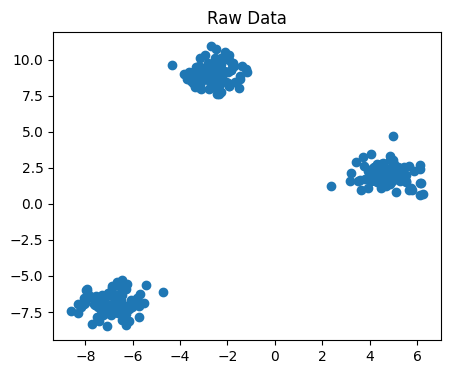

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52286 (\N{HANGUL SYLLABLE CAJ}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


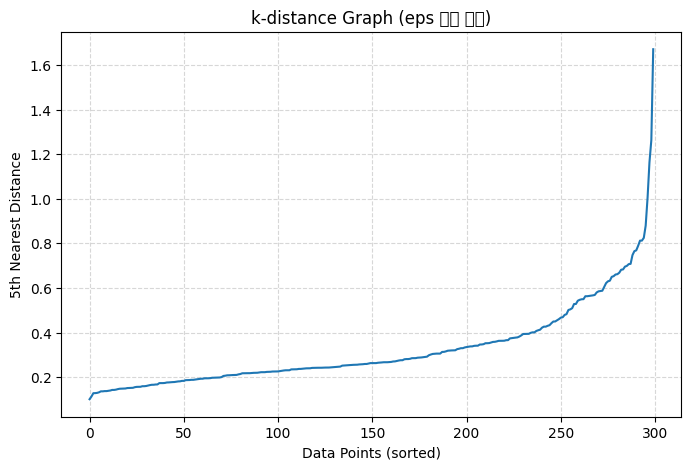

🔥 추천 eps (대략): 0.58


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors

# =========================
# 1️⃣ 데이터 생성 (DBSCAN용)
# =========================
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.7,
    random_state=42
)

plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1])
plt.title("Raw Data")
plt.show()


# =========================
# 2️⃣ k 설정 (핵심)
# =========================
k = 5   # 보통 min_samples와 동일하게 설정

# =========================
# 3️⃣ k-NN 거리 계산
# =========================
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(X)
distances, indices = nbrs.kneighbors(X)


# =========================
# 4️⃣ k번째 거리 추출
# =========================
k_distances = distances[:, k-1]

# 정렬 (핵심)
k_distances = np.sort(k_distances)


# =========================
# 5️⃣ k-distance graph
# =========================
plt.figure(figsize=(8,5))

plt.plot(k_distances)

plt.title("k-distance Graph (eps 후보 찾기)")
plt.xlabel("Data Points (sorted)")
plt.ylabel(f"{k}th Nearest Distance")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


# =========================
# 6️⃣ eps 선택 힌트 출력
# =========================
eps_estimate = np.percentile(k_distances, 90) # 90%가 이 값 이하

# 예)  eps = 1.2 eps_estimate = np.percentile(k_distances, 90)
# → 전체 데이터의 90%
# 1.2 거리 안에 이웃이 존재

print("🔥 추천 eps (대략):", round(eps_estimate, 3)) #상위 10% 정도 큰 거리(이상치 후보)는 제외 , 나머지 90% 데이터를 포함하도록 선택

# eps가 너무 작으면:
# 거의 전부 Noise

In [ ]:
# 📘 K-Distance Graph 완전 이해 (DBSCAN eps 선택 핵심)
# DBSCAN 알고리즘에서 가장 중요한 하이퍼파라미터인 eps를 결정하는 핵심 개념, k-distance graph를 숫자 예제로 완벽히 이해하기 위한 가이드.

# 🔥 1. k-distance란?
# 한 줄 정의: 각 점에서 가장 가까운 
# 번째 이웃까지의 거리.
# 핵심 의미: "내 주변에서 
# 번째로 가까운 점까지의 거리"를 뜻함.
# 📌 2. 예제 데이터
# 다음과 같은 5개의 2차원 데이터 포인트 예시 (조건: 
# ).

# A (0,0)
# B (0,1)
# C (0,2)
# D (5,5)
# E (5,6)
# 🔥 3. 각 점의 k-distance 계산
# 📍 A 기준
# A에서 다른 점까지의 거리:
# A → B = 1
# A → C = 2
# A → D ≈ 7.07
# A → E ≈ 7.81
# 오름차순 정렬: 1, 2, 7.07, 7.81
# 결과: 2번째로 가까운 거리 선택 
#  k-distance(A) = 2
# 📍 B 기준
# B에서 다른 점까지의 거리:
# B → A = 1
# B → C = 1
# B → D ≈ 6.4
# B → E ≈ 7.1
# 오름차순 정렬: 1, 1, 6.4, 7.1
# 결과: 2번째로 가까운 거리 선택 
#  k-distance(B) = 1
# 📍 C 기준
# C에서 다른 점까지의 거리:
# C → B = 1
# C → A = 2
# C → D ≈ 5.4
# C → E ≈ 6.1
# 오름차순 정렬: 1, 2, 5.4, 6.1
# 결과: 2번째로 가까운 거리 선택 
#  k-distance(C) = 2
# 📍 D 기준 (멀리 있는 점)
# D에서 다른 점까지의 거리:
# D → E = 1
# D → C ≈ 5.4
# D → B ≈ 6.4
# D → A ≈ 7.07
# 오름차순 정렬: 1, 5.4, 6.4, 7.07
# 결과: 2번째로 가까운 거리 선택 
#  k-distance(D) = 5.4
# 📍 E 기준
# E에서 다른 점까지의 거리:
# E → D = 1
# E → C ≈ 4.1
# E → B ≈ 5.1
# E → A ≈ 7.8
# 오름차순 정렬: 1, 4.1, 5.1, 7.8
# 결과: 2번째로 가까운 거리 선택 
#  k-distance(E) = 4.1
# 📌 4. 최종 k-distance 값
# 모든 데이터 포인트의 k-distance 계산 결과 취합.

# A → 2
# B → 1
# C → 2
# D → 5.4
# E → 4.1
# 🔥 5. 오름차순 정렬 결과
# 그래프 시각화를 위해 위 값을 크기순으로 나열함.

# 1 → 2 → 2 → 4.1 → 5.4

# 📌 6. 수치가 의미하는 바
# 작은 값 (
# ): 데이터가 촘촘하게 모여 있는 밀집 영역 (Cluster 내부).
# 큰 값 (
# ): 데이터가 서로 멀리 떨어진 희소 영역 (경계면 또는 Noise).
# 🔥 7. 핵심 연결
# k-distance graph의 본질: 각 데이터 포인트의 현지 밀도를 거리 단위의 숫자로 바꾸어 정렬한 형태임.
# 📌 8. eps 도출 방법
# 정렬된 그래프 추이에서 완만하다가 급격히 수직 상승하기 직전의 꺾이는 지점(Elbow Point)을 포착함.
# 해당 꺾임점의 y축 거리 값을 DBSCAN의 최종 eps 후보로 판단함.